In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

In [2]:
data = pd.read_csv("data/train.csv")
data.head()

,id,loan_amount,loan_to_value_ratio,property_value,income,loan_term,total_units,state_code,derived_msa-md,county_code,...,initially_payable_to_institution,aus-1,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units,accepted
0,544438,705000.0,46.823,1495000.0,655.0,360.0,1.0,CA,34900,6055.0,...,1,1,4493,49.83,121100,78,1094,1486,55,1
1,316090,295000.0,53.000,555000.0,63.0,360.0,1.0,NC,99999,37113.0,...,1,6,1604,13.22,71500,140,547,2188,39,1
2,153632,305000.0,80.000,385000.0,109.0,360.0,1.0,VA,40060,51087.0,...,1,1,4780,40.92,110000,71,781,1527,53,1
3,400700,765000.0,58.970,1305000.0,190.0,360.0,1.0,NC,16740,37179.0,...,1,1,7126,32.88,100300,273,1991,2094,0,1
4,205569,1775000.0,60.000,2955000.0,15675.0,360.0,1.0,FL,33124,12086.0,...,1,1,6006,53.48,79400,167,1043,723,56,0


In [3]:
data.isnull().sum()

id                                              0
loan_amount                                     0
loan_to_value_ratio                         11874
property_value                               4756
income                                       4578
loan_term                                    3307
total_units                                   437
state_code                                    824
derived_msa-md                                  0
county_code                                  1339
conforming_loan_limit                         437
derived_loan_product_type                       0
derived_dwelling_category                       0
loan_type                                       0
lien_status                                     0
preapproval                                     0
reverse_mortgage                                0
open-end_line_of_credit                         0
business_or_commercial_purpose                  0
negative_amortization                           0


In [4]:
X = data.drop(columns=["accepted", "id"])
X = X.dropna(axis=1)
Y = data["accepted"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

num_cols = X_train.select_dtypes(include=["number"]).columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            cat_cols,
        ),
    ]
)


X_train_normed = preprocessor.fit_transform(X_train)
X_test_normed = preprocessor.transform(X_test)

X

/var/folders/_x/n95gs3252rgc51_6w0jltchc0000gn/T/ipykernel_583/444162830.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object", "category"]).columns


,loan_amount,derived_msa-md,derived_loan_product_type,derived_dwelling_category,loan_type,lien_status,preapproval,reverse_mortgage,open-end_line_of_credit,business_or_commercial_purpose,...,submission_of_application,initially_payable_to_institution,aus-1,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,705000.0,34900,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,2,2,2,1,...,1,1,1,4493,49.83,121100,78,1094,1486,55
1,295000.0,99999,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,2,2,2,2,...,1,1,6,1604,13.22,71500,140,547,2188,39
2,305000.0,40060,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,2,2,2,2,...,1,1,1,4780,40.92,110000,71,781,1527,53
3,765000.0,16740,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,2,2,2,2,...,1,1,1,7126,32.88,100300,273,1991,2094,0
4,1775000.0,33124,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,2,2,2,2,...,1,1,1,6006,53.48,79400,167,1043,723,56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104995,125000.0,26580,FHA:First Lien,Single Family (1-4 Units):Site-Built,2,1,2,2,2,2,...,1,1,1,4361,8.55,74300,107,1284,2026,54
104996,305000.0,36084,FHA:First Lien,Single Family (1-4 Units):Site-Built,2,1,2,2,2,2,...,1,1,3,7484,77.59,155700,35,993,1809,41
104997,265000.0,20994,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,2,2,2,2,...,1,2,6,3726,63.23,113700,92,794,1146,17
104998,645000.0,99999,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,2,2,1,...,1,1,1,3096,10.95,80300,165,776,1770,29


In [5]:

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_normed, Y_train)


y_pred = lr_model.predict(X_test_normed) 
y_proba = lr_model.predict_proba(X_test_normed)[
    :, 1
]  

print("=== MÉTRIQUES PRINCIPALES ===")
print(f"Accuracy  : {accuracy_score(Y_test, y_pred):.4f}")
print(f"Precision : {precision_score(Y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(Y_test, y_pred):.4f}")
print(f"F1-Score  : {f1_score(Y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(Y_test, y_proba):.4f}")

print("\n=== RAPPORT DE CLASSIFICATION ===")
print(classification_report(Y_test, y_pred))


=== MÉTRIQUES PRINCIPALES ===
Accuracy  : 0.8759
Precision : 0.8927
Recall    : 0.9704
F1-Score  : 0.9299
ROC-AUC   : 0.7627

=== RAPPORT DE CLASSIFICATION ===
              precision    recall  f1-score   support

           0       0.67      0.34      0.46      3966
           1       0.89      0.97      0.93     22284

    accuracy                           0.88     26250
   macro avg       0.78      0.66      0.69     26250
weighted avg       0.86      0.88      0.86     26250



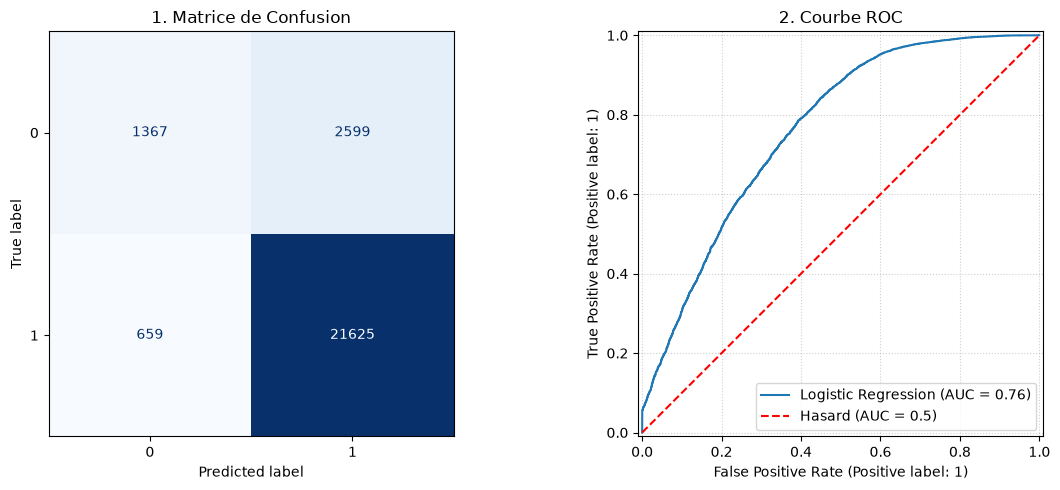

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


ConfusionMatrixDisplay.from_predictions(
    Y_test, y_pred, ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("1. Matrice de Confusion")

RocCurveDisplay.from_predictions(
    Y_test, y_proba, ax=axes[1], name="Logistic Regression"
)
axes[1].plot([0, 1], [0, 1], "r--", label="Hasard (AUC = 0.5)")
axes[1].set_title("2. Courbe ROC")
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
data_test = pd.read_csv("data/test.csv")

data_test

X_test = data_test.drop(columns=["id"]).dropna(axis=1)

num_cols = X_train.select_dtypes(include=["number"]).columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

X_train_normed = preprocessor.fit_transform(X_train)
X_test_normed = preprocessor.transform(X_test)

id = data_test[["id"]]
pred_test = lr_model.predict(X_test_normed)


submission = pd.DataFrame({
    "id": data_test["id"],
    "accepted": pred_test.flatten() 
})

submission.to_csv("lr_submission.csv", index=False)


/var/folders/_x/n95gs3252rgc51_6w0jltchc0000gn/T/ipykernel_583/1849962534.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object", "category"]).columns
